<a href="https://colab.research.google.com/github/gamuchiraimapear/HASTS211-ASSIGNMENTS/blob/main/Gamuchirai_Mapiye_R2420904financial_econometrics_project1_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Gamuchirai Mapiye R2420904 Financial Econometrics — Project #1
## Best-Practices Handbook: Volatility Modeling Challenges

**Scenario:** As newly hired quants on the derivatives desk, we model volatility for traders and risk managers using Apple Inc. (AAPL) stock data from 2018–2025.

**Four Challenges Addressed:**
1. Multicollinearity
2. Skewness
3. Sensitivity to Outliers
4. Overfitting

---

## Setup & Data Download
Download Apple Inc. (AAPL) historical data from 2018-01-01 to 2025-12-31 using the yfinance API.

In [ ]:
# Install required libraries (run once)
!pip install yfinance pandas numpy matplotlib seaborn statsmodels scikit-learn scipy --quiet

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# ── Download AAPL data ──────────────────────────────────────────────────────
ticker = 'AAPL'
start_date = '2018-01-01'
end_date   = '2025-12-31'

aapl = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)
aapl.columns = aapl.columns.get_level_values(0)   # flatten MultiIndex if present

print(f'Downloaded {len(aapl)} trading days of AAPL data ({start_date} → {end_date})')
aapl.head()

[*********************100%***********************]  1 of 1 completed

Downloaded 2010 trading days of AAPL data (2018-01-01 → 2025-12-31)


Price,Close,High,Low,Open,Volume
Date,,,,,
2018-01-02,40.304173,40.313533,39.602254,39.812832,102223600
2018-01-03,40.297153,40.839972,40.233983,40.367346,118071600
2018-01-04,40.484341,40.587289,40.262067,40.369693,89738400
2018-01-05,40.945259,41.031828,40.489013,40.580262,94640000
2018-01-08,40.793186,41.087991,40.694914,40.793186,82271200


In [ ]:
# ── Feature Engineering ─────────────────────────────────────────────────────
df = aapl.copy()

# Log returns
df['Log_Return']  = np.log(df['Close'] / df['Close'].shift(1))

# Realised volatility (21-day rolling std of log returns, annualised)
df['Volatility']  = df['Log_Return'].rolling(21).std() * np.sqrt(252)

# Technical features (potential regressors)
df['MA_5']        = df['Close'].rolling(5).mean()
df['MA_21']       = df['Close'].rolling(21).mean()
df['MA_63']       = df['Close'].rolling(63).mean()
df['RSI_14']      = 100 - (100 / (1 + df['Log_Return'].rolling(14)
                            .apply(lambda x: x[x>0].mean() / (-x[x<0].mean()
                                   if len(x[x<0]) else 1e-9))))
df['Momentum_21'] = df['Close'] / df['Close'].shift(21) - 1
df['Volume_MA5']  = df['Volume'].rolling(5).mean()
df['High_Low']    = df['High'] - df['Low']
df['Close_Open']  = df['Close'] - df['Open']

df.dropna(inplace=True)
print(f'Feature matrix shape: {df.shape}')
df[['Close','Log_Return','Volatility']].describe().round(4)

Feature matrix shape: (1948, 15)


Price,Close,Log_Return,Volatility
count,1948.0000,1948.0000,1948.0000
mean,138.3443,0.0010,0.2797
std,65.5303,0.0195,0.1347
min,33.7681,-0.1377,0.0958
25%,70.9510,-0.0078,0.1927
50%,144.6557,0.0013,0.2487
75%,184.6510,0.0111,0.3238
max,285.9225,0.1426,1.0688


---
# Challenge 1 — Multicollinearity

---

### Definition

Multicollinearity arises when two or more predictor variables $X_j$ are approximately linearly dependent. Formally, there exist constants $c_1, c_2, \ldots, c_k$ (not all zero) such that:

$$c_1 X_1 + c_2 X_2 + \cdots + c_k X_k \approx 0$$

A common scalar measure is the **Variance Inflation Factor (VIF)**:

$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$

where $R_j^2$ is the coefficient of determination from regressing $X_j$ on all other predictors. A $\text{VIF}_j > 10$ is conventionally considered severe.

### Description

Multicollinearity occurs when predictors in a regression model are highly correlated with one another, making it difficult to isolate the individual effect of each variable. It does not bias the estimates themselves, but inflates their standard errors, destabilizing coefficient estimates and reducing statistical power.

In [ ]:
# ── Demonstration ───────────────────────────────────────────────────────────
features_mc = ['MA_5', 'MA_21', 'MA_63', 'Momentum_21', 'High_Low', 'Close_Open']
X_mc = df[features_mc].copy()

# Correlation matrix
corr = X_mc.corr().round(3)
print('Correlation Matrix:')
print(corr)

# VIF scores
X_const = add_constant(X_mc)
vif_data = pd.DataFrame({
    'Feature': features_mc,
    'VIF'    : [variance_inflation_factor(X_const.values, i+1)
                for i in range(len(features_mc))]
}).sort_values('VIF', ascending=False)

print('\nVIF Scores:')
print(vif_data.round(2))

Correlation Matrix:
Price         MA_5  MA_21  MA_63  Momentum_21  High_Low  Close_Open
Price                                                              
MA_5         1.000  0.997  0.988       -0.006     0.565       0.021
MA_21        0.997  1.000  0.994       -0.062     0.581       0.021
MA_63        0.988  0.994  1.000       -0.113     0.589       0.027
Momentum_21 -0.006 -0.062 -0.113        1.000    -0.187       0.101
High_Low     0.565  0.581  0.589       -0.187     1.000       0.046
Close_Open   0.021  0.021  0.027        0.101     0.046       1.000

VIF Scores:
       Feature     VIF
1        MA_21  493.36
0         MA_5  393.40
2        MA_63  105.49
3  Momentum_21    2.57
4     High_Low    1.60
5   Close_Open    1.04


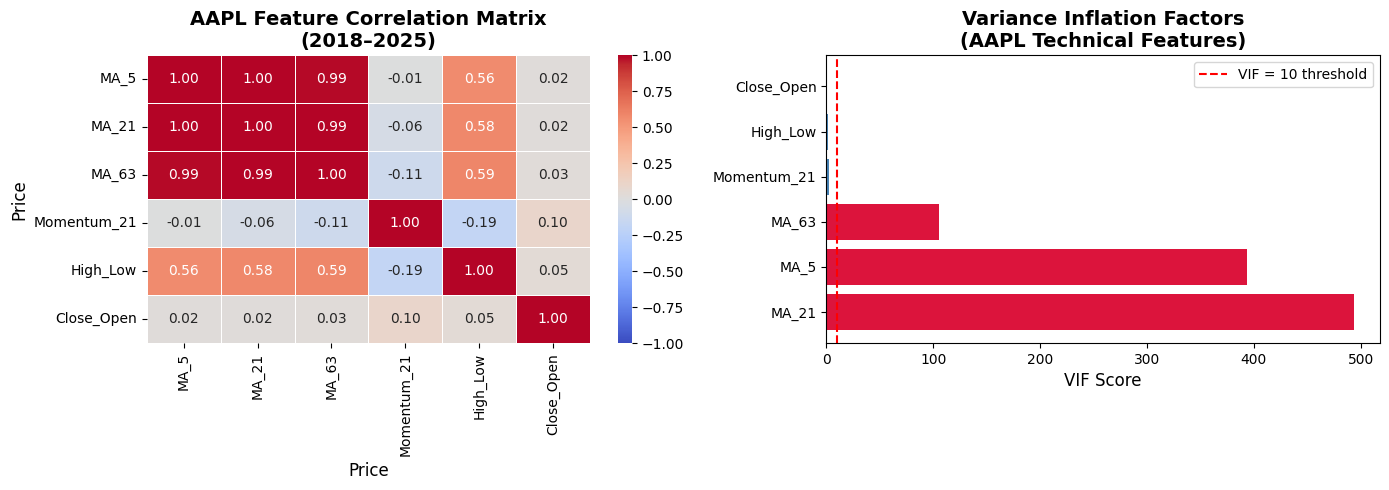

Figure saved.


In [ ]:
# ── Diagram ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heat-map
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=axes[0], linewidths=0.5)
axes[0].set_title('AAPL Feature Correlation Matrix\n(2018–2025)', fontweight='bold')

# VIF bar chart
colors = ['crimson' if v > 10 else 'steelblue' for v in vif_data['VIF']]
axes[1].barh(vif_data['Feature'], vif_data['VIF'], color=colors)
axes[1].axvline(10, color='red', linestyle='--', label='VIF = 10 threshold')
axes[1].set_xlabel('VIF Score')
axes[1].set_title('Variance Inflation Factors\n(AAPL Technical Features)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('multicollinearity_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

### Diagnosis

1. **Correlation Matrix** — pairwise correlations $|r| > 0.8$ signal potential multicollinearity.
2. **VIF** — $\text{VIF} > 10$ (or conservatively $> 5$) on any predictor confirms the problem.
3. **Condition Number** — eigenvalue-based condition index $> 30$ is a further red flag.
4. **Sign flips** — unexpected coefficient signs when adding/removing predictors.

### Damage

Multicollinearity inflates standard errors, making individually significant predictors appear statistically insignificant (high $p$-values). It also produces unstable, highly sensitive coefficient estimates that can change dramatically with small data perturbations, rendering inference unreliable even though in-sample $R^2$ can remain high.

### Directions (Remedies)

| Approach | Mechanism |
|---|---|
| **Remove redundant features** | Drop one of a highly correlated pair |
| **Ridge Regression ($L_2$)** | Adds $\lambda \sum \beta_j^2$ penalty; shrinks correlated coefficients together |
| **Lasso Regression ($L_1$)** | Adds $\lambda \sum |\beta_j|$ penalty; performs automatic variable selection |
| **Principal Component Regression** | Orthogonalizes the feature space before regression |
| **Domain-based feature selection** | Use theory to retain only economically meaningful predictors |

---
# Challenge 2 — Skewness

---

### Definition

Skewness is the third standardised central moment of a distribution:

$$\gamma_1 = \frac{\mu_3}{\sigma^3} = \frac{\frac{1}{n}\sum_{i=1}^{n}(X_i - \bar{X})^3}
                                          {\left[\frac{1}{n}\sum_{i=1}^{n}(X_i - \bar{X})^2\right]^{3/2}}$$

$\gamma_1 = 0$ for a symmetric distribution; $\gamma_1 > 0$ indicates a right (positive) tail; $\gamma_1 < 0$ indicates a left (negative) tail.

### Description

Skewness measures the asymmetry of the return distribution around its mean. Financial returns typically exhibit negative skewness (left tail), reflecting that large losses are more probable than gains of equal magnitude — a critical consideration for derivatives pricing and risk management.

In [ ]:
# ── Demonstration ───────────────────────────────────────────────────────────
returns = df['Log_Return'].dropna()

skew_val = stats.skew(returns)
kurt_val = stats.kurtosis(returns)   # excess kurtosis
jb_stat, jb_p = stats.jarque_bera(returns)

print('=== AAPL Log-Return Distribution Statistics ===')
print(f'  Mean      : {returns.mean():.6f}')
print(f'  Std Dev   : {returns.std():.6f}')
print(f'  Skewness  : {skew_val:.4f}  (Normal = 0)')
print(f'  Excess Kurt: {kurt_val:.4f}  (Normal = 0)')
print(f'  Jarque-Bera: stat = {jb_stat:.2f},  p-value = {jb_p:.4e}')
print(f'  Normality rejected: {jb_p < 0.05}')

=== AAPL Log-Return Distribution Statistics ===
  Mean      : 0.000997
  Std Dev   : 0.019456
  Skewness  : -0.0967  (Normal = 0)
  Excess Kurt: 6.2752  (Normal = 0)
  Jarque-Bera: stat = 3199.22,  p-value = 0.0000e+00
  Normality rejected: True


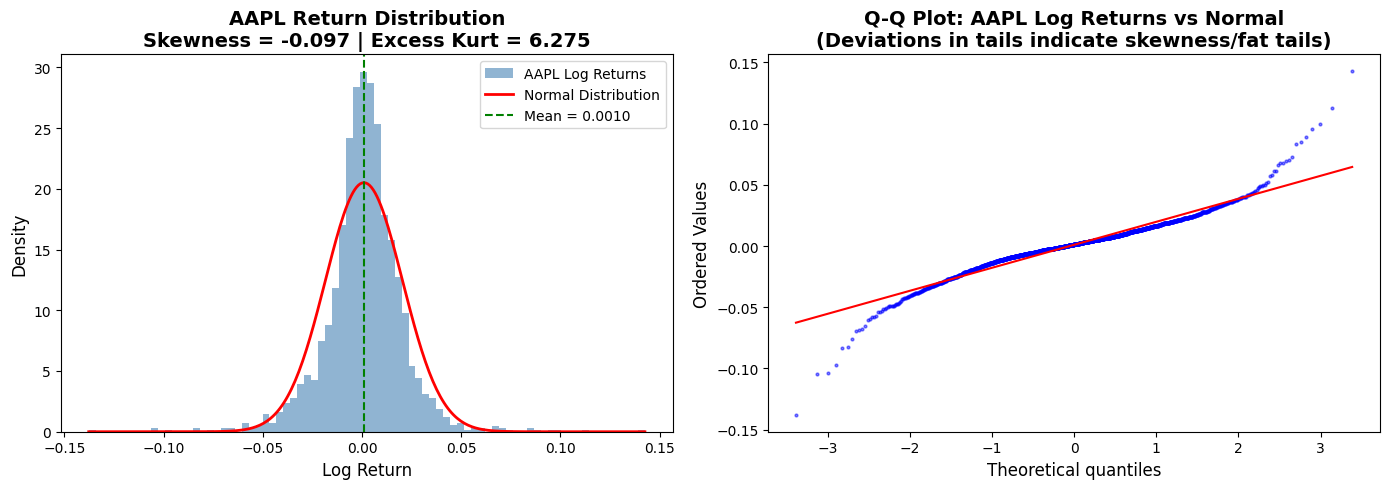

Figure saved.


In [ ]:
# ── Diagram ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with normal overlay
x_range = np.linspace(returns.min(), returns.max(), 300)
normal_pdf = stats.norm.pdf(x_range, returns.mean(), returns.std())

axes[0].hist(returns, bins=80, density=True, color='steelblue',
             alpha=0.6, label='AAPL Log Returns')
axes[0].plot(x_range, normal_pdf, 'r-', lw=2, label='Normal Distribution')
axes[0].axvline(returns.mean(), color='green', linestyle='--', lw=1.5,
                label=f'Mean = {returns.mean():.4f}')
axes[0].set_xlabel('Log Return')
axes[0].set_ylabel('Density')
axes[0].set_title(f'AAPL Return Distribution\nSkewness = {skew_val:.3f} | Excess Kurt = {kurt_val:.3f}',
                  fontweight='bold')
axes[0].legend()

# Q-Q plot
stats.probplot(returns, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot: AAPL Log Returns vs Normal\n(Deviations in tails indicate skewness/fat tails)',
                  fontweight='bold')
axes[1].get_lines()[0].set(markersize=2, alpha=0.5)

plt.tight_layout()
plt.savefig('skewness_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

### Diagnosis

1. **Skewness coefficient** — $|\gamma_1| > 0.5$ is moderate; $|\gamma_1| > 1$ is severe.
2. **Jarque-Bera test** — jointly tests $\gamma_1 = 0$ and $\kappa = 3$; rejection ($p < 0.05$) indicates non-normality.
3. **Q-Q plot** — systematic deviation from the 45° line, especially in tails, reveals skewness.
4. **Histogram** — visual asymmetry around the mode.

### Damage

Skewness violates the normality assumption underlying OLS inference and many option-pricing models (e.g., Black-Scholes). Ignoring negative skewness causes systematic underestimation of downside risk, leading to mispriced options (especially puts), inadequate Value-at-Risk estimates, and flawed hedging strategies.

### Directions (Remedies)

| Approach | Mechanism |
|---|---|
| **Log/Box-Cox transformation** | Reduce skewness in the response variable |
| **Skew-t or GED distributions** | Replace normality assumption in GARCH with fat-tailed, skewed distributions |
| **Gram-Charlier / Cornish-Fisher expansion** | Explicitly incorporate skewness/kurtosis into density approximations |
| **Non-parametric / robust methods** | Quantile regression, bootstrap confidence intervals |
| **Jump-diffusion models** | Capture sudden large moves that generate skewness (Merton 1976) |

---
# Challenge 3 — Sensitivity to Outliers

---

### Definition

An observation $y_i$ is an outlier when its standardised residual $|e_i^*| > 3$, or when it exerts disproportionate influence on the fitted model. Influence is measured by **Cook's Distance**:

$$D_i = \frac{(\hat{\boldsymbol{\beta}} - \hat{\boldsymbol{\beta}}_{(-i)})^\top (X^\top X)(\hat{\boldsymbol{\beta}} - \hat{\boldsymbol{\beta}}_{(-i)})}{k\,\hat{\sigma}^2}$$

where $\hat{\boldsymbol{\beta}}_{(-i)}$ is the estimate with observation $i$ removed, $k$ is the number of parameters, and $\hat{\sigma}^2$ is the residual variance. A common threshold is $D_i > 4/n$.

### Description

Outliers are data points that deviate markedly from the bulk of observations. In financial time series they frequently correspond to market crashes, earnings surprises, or macro shocks. OLS minimizes the *sum of squared* residuals, making it particularly sensitive to extreme observations that can distort coefficient estimates.

In [ ]:
# ── Demonstration ───────────────────────────────────────────────────────────
ret = df['Log_Return'].copy()

# Z-score outlier detection
z_scores  = np.abs(stats.zscore(ret))
outlier_mask = z_scores > 3
outliers  = df[outlier_mask][['Close', 'Log_Return']]

print(f'Total trading days  : {len(ret)}')
print(f'Outliers (|z| > 3)  : {outlier_mask.sum()}')
print(f'Outlier percentage  : {outlier_mask.mean()*100:.2f}%')
print()
print('Top 10 largest daily moves:')
top10 = df['Log_Return'].abs().nlargest(10)
print(df.loc[top10.index, ['Close', 'Log_Return']].round(4))

Total trading days  : 1948
Outliers (|z| > 3)  : 30
Outlier percentage  : 1.54%

Top 10 largest daily moves:
Price          Close  Log_Return
Date                            
2025-04-09  197.9871      0.1426
2020-03-16   58.5242     -0.1377
2020-03-13   67.1647      0.1132
2019-01-03   33.7681     -0.1049
2020-03-12   59.9788     -0.1040
2020-07-31  102.9787      0.0996
2025-04-03  202.3082     -0.0970
2020-03-24   59.6526      0.0956
2020-03-02   72.2003      0.0890
2022-11-10  144.5519      0.0852


In [ ]:
# Compare OLS with and without outliers
X_feat = df[['High_Low']].copy()
y_feat = df['Log_Return'].copy()

model_all   = OLS(y_feat, add_constant(X_feat)).fit()
model_clean = OLS(y_feat[~outlier_mask],
                  add_constant(X_feat[~outlier_mask])).fit()

print('=== OLS: High-Low Range → Log Return ===')
print(f'WITH outliers    — slope: {model_all.params[1]:.6f},  R²: {model_all.rsquared:.4f}')
print(f'WITHOUT outliers — slope: {model_clean.params[1]:.6f},  R²: {model_clean.rsquared:.4f}')

=== OLS: High-Low Range → Log Return ===
WITH outliers    — slope: -0.000360,  R²: 0.0016
WITHOUT outliers — slope: -0.000919,  R²: 0.0126


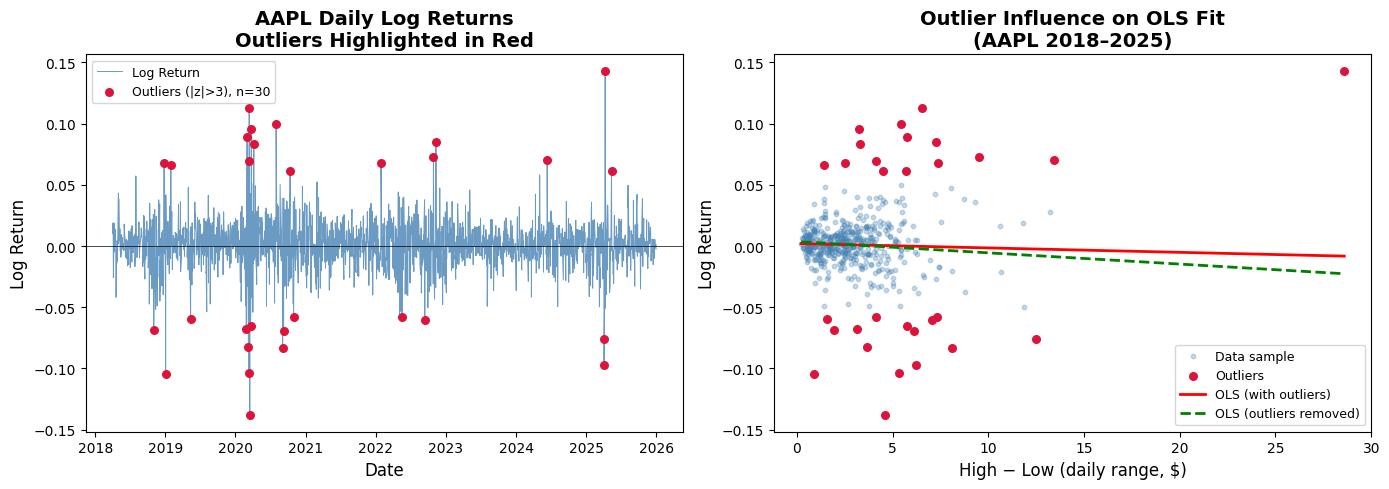

Figure saved.


In [ ]:
# ── Diagram ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time-series with outliers highlighted
axes[0].plot(df.index, ret, color='steelblue', lw=0.7, alpha=0.8, label='Log Return')
axes[0].scatter(df.index[outlier_mask], ret[outlier_mask],
                color='crimson', s=30, zorder=5, label=f'Outliers (|z|>3), n={outlier_mask.sum()}')
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Log Return')
axes[0].set_title('AAPL Daily Log Returns\nOutliers Highlighted in Red', fontweight='bold')
axes[0].legend(fontsize=9)

# Scatter: High-Low vs Return — OLS with vs without outliers
sample = df.sample(500, random_state=42)
axes[1].scatter(sample['High_Low'], sample['Log_Return'],
                alpha=0.3, s=10, color='steelblue', label='Data sample')
axes[1].scatter(df.loc[outlier_mask, 'High_Low'],
                df.loc[outlier_mask, 'Log_Return'],
                color='crimson', s=30, zorder=5, label='Outliers')

xl = np.linspace(df['High_Low'].min(), df['High_Low'].max(), 200)
axes[1].plot(xl, model_all.params[0]   + model_all.params[1]  *xl,
             'r-', lw=2, label='OLS (with outliers)')
axes[1].plot(xl, model_clean.params[0] + model_clean.params[1]*xl,
             'g--', lw=2, label='OLS (outliers removed)')
axes[1].set_xlabel('High − Low (daily range, $)')
axes[1].set_ylabel('Log Return')
axes[1].set_title('Outlier Influence on OLS Fit\n(AAPL 2018–2025)', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('outlier_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

### Diagnosis

1. **Z-score / Modified Z-score** — $|z_i| > 3$ flags a potential outlier.
2. **Cook's Distance** — $D_i > 4/n$ identifies influential observations.
3. **IQR rule** — values outside $[Q_1 - 1.5 \text{IQR},\; Q_3 + 1.5 \text{IQR}]$.
4. **Residual vs Leverage plot** — standard diagnostic after OLS.

### Damage

Because OLS squares residuals, a single extreme observation can dominate the loss function and dramatically shift slope estimates, inflating or deflating volatility forecasts. This distorts option prices, Value-at-Risk, and hedging ratios—potentially by more than the single event warrants.

### Directions (Remedies)

| Approach | Mechanism |
|---|---|
| **Robust regression (Huber / LAD)** | Down-weights or ignores extreme residuals |
| **Winsorisation / Trimming** | Caps values at chosen quantiles |
| **Student-t GARCH** | Fat-tailed innovation distribution naturally accommodates jumps |
| **Jump-diffusion (Merton)** | Explicitly models discrete jumps separate from diffusion |
| **Influence diagnostics** | Iterative removal and re-estimation; Cook's $D$ ≤ $4/n$ |

---
# Challenge 4 — Overfitting

---

### Definition

Overfitting occurs when a model learns the noise in the training sample rather than the underlying data-generating process. The bias-variance decomposition formalizes this trade-off:

$$\text{MSE}(\hat{f}(x)) = \underbrace{\left[\text{Bias}(\hat{f}(x))\right]^2}_{\text{systematic error}} + \underbrace{\text{Var}(\hat{f}(x))}_{\text{sampling variability}} + \sigma^2_{\varepsilon}$$

Overfitting minimizes in-sample bias at the cost of high variance, so that out-of-sample MSE increases even as in-sample $R^2 \to 1$.

### Description

An overfitted model is overly complex relative to the available data, capturing idiosyncratic fluctuations in the training set that do not generalize. In volatility modeling this leads to forecasts that look impressive in-sample but perform poorly on new data, undermining derivative pricing and risk management.

In [ ]:
# ── Demonstration ───────────────────────────────────────────────────────────
# Predict next-day volatility using polynomial expansion of lag-1 volatility
vol = df['Volatility'].dropna().values
X_vol = vol[:-1].reshape(-1, 1)   # lag-1 volatility
y_vol = vol[1:]                   # next-day volatility

X_tr, X_te, y_tr, y_te = train_test_split(X_vol, y_vol, test_size=0.2, shuffle=False)

degrees = [1, 3, 6, 10, 15]
results = []

for deg in degrees:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(deg, include_bias=False)),
        ('scale', StandardScaler()),
        ('reg',   LinearRegression())
    ])
    pipe.fit(X_tr, y_tr)
    train_mse = mean_squared_error(y_tr, pipe.predict(X_tr))
    test_mse  = mean_squared_error(y_te, pipe.predict(X_te))
    cv_mse    = -cross_val_score(pipe, X_tr, y_tr, cv=5,
                                 scoring='neg_mean_squared_error').mean()
    results.append({'Degree': deg,
                    'Train MSE': train_mse,
                    'Test MSE' : test_mse,
                    'CV MSE'  : cv_mse})

res_df = pd.DataFrame(results).set_index('Degree')
print('=== Polynomial Regression: Volatility Forecasting ===')
print(res_df.applymap(lambda x: f'{x:.6f}'))

=== Polynomial Regression: Volatility Forecasting ===
       Train MSE  Test MSE               CV MSE
Degree                                         
1       0.000418  0.000624             0.000420
3       0.000417  0.000625             0.001134
6       0.000417  0.000626            22.140131
10      0.000412  0.000660      25939755.670465
15      0.000409  0.000764  632875717138.337402


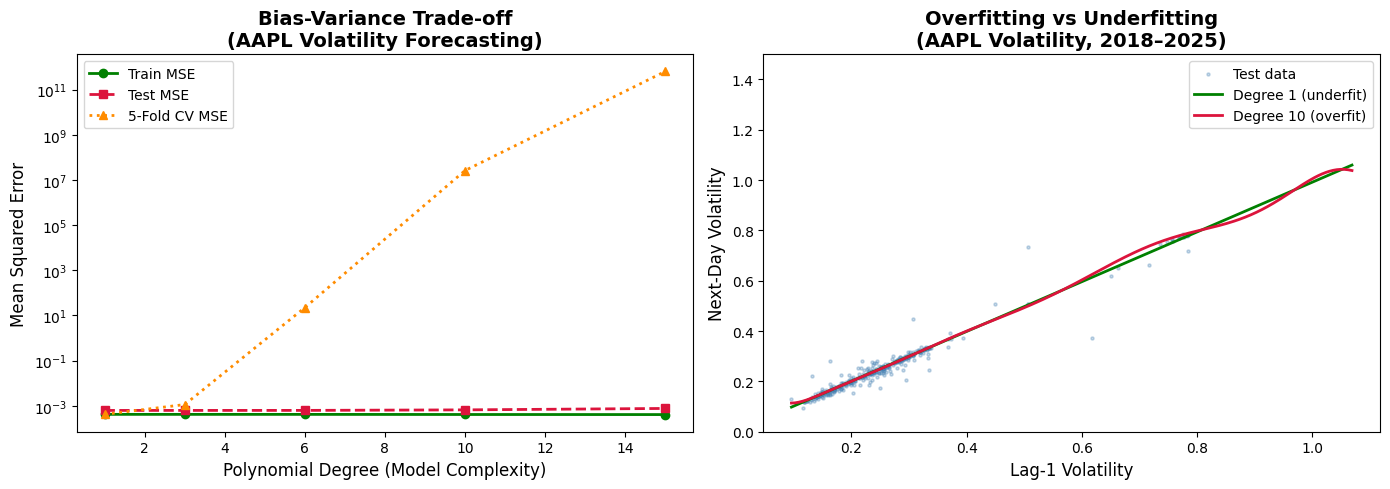

Figure saved.


In [ ]:
# ── Diagram ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Learning curves: train vs test MSE by model complexity
axes[0].plot(res_df.index, res_df['Train MSE'], 'o-', color='green',
             lw=2, label='Train MSE')
axes[0].plot(res_df.index, res_df['Test MSE'],  's--', color='crimson',
             lw=2, label='Test MSE')
axes[0].plot(res_df.index, res_df['CV MSE'],    '^:', color='darkorange',
             lw=2, label='5-Fold CV MSE')
axes[0].set_xlabel('Polynomial Degree (Model Complexity)')
axes[0].set_ylabel('Mean Squared Error')
axes[0].set_title('Bias-Variance Trade-off\n(AAPL Volatility Forecasting)', fontweight='bold')
axes[0].legend()
axes[0].set_yscale('log')

# Fitted curves for degree 1 vs degree 10
x_plot = np.linspace(X_vol.min(), X_vol.max(), 300).reshape(-1, 1)
colors_deg = {1: 'green', 10: 'crimson'}
labels_deg = {1: 'Degree 1 (underfit)', 10: 'Degree 10 (overfit)'}

axes[1].scatter(X_te, y_te, s=5, alpha=0.3, color='steelblue', label='Test data')
for deg in [1, 10]:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(deg, include_bias=False)),
        ('scale', StandardScaler()),
        ('reg',   LinearRegression())
    ])
    pipe.fit(X_tr, y_tr)
    axes[1].plot(x_plot, pipe.predict(x_plot),
                 color=colors_deg[deg], lw=2, label=labels_deg[deg])

axes[1].set_xlabel('Lag-1 Volatility')
axes[1].set_ylabel('Next-Day Volatility')
axes[1].set_title('Overfitting vs Underfitting\n(AAPL Volatility, 2018–2025)', fontweight='bold')
axes[1].legend()
axes[1].set_ylim(0, 1.5)

plt.tight_layout()
plt.savefig('overfitting_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

### Diagnosis

1. **Train vs Test MSE gap** — large divergence indicates overfit.
2. **Cross-validation** — $k$-fold CV MSE substantially above train MSE confirms the problem.
3. **AIC / BIC** — information criteria penalise complexity; a rising BIC with additional parameters signals overfit.
4. **Learning curves** — plotting error vs training set size; if train error ≪ validation error at full data, the model is overfit.

### Damage

An overfitted volatility model produces forecasts that are unreliable out-of-sample, leading to mispriced derivatives, incorrect hedge ratios, and overstated confidence in risk metrics such as Value-at-Risk. Losses incurred from acting on faulty forecasts can far exceed any in-sample gains suggested by the model.

### Directions (Remedies)

| Approach | Mechanism |
|---|---|
| **Regularization (Ridge / Lasso)** | Penalises coefficient magnitude to reduce variance |
| **Cross-validation for model selection** | Chooses model complexity based on out-of-sample performance |
| **GARCH family models** | Parsimonious, theory-grounded volatility specifications (1-2 parameters) |
| **Early stopping** | Halt training when validation error begins rising |
| **Information criteria (AIC/BIC)** | Formal complexity penalty to select optimal lag order |
| **Walk-forward validation** | Respects time ordering when assessing forecast skill |

---
# Summary & Practical Takeaways

---

| Challenge | Key Test | Primary Remedy |
|---|---|---|
| Multicollinearity | VIF > 10 | Ridge / Lasso regression |
| Skewness | Jarque-Bera; $|\gamma_1| > 0.5$ | Skew-t GARCH; log transform |
| Outlier Sensitivity | $|z| > 3$; Cook's $D > 4/n$ | Robust regression; winsorisation |
| Overfitting | Train MSE ≪ Test MSE; BIC rising | Cross-validation; regularization |

**Practical takeaway for derivatives desks:** A robust volatility model must simultaneously (i) use low-collinearity features, (ii) accommodate return skewness in innovation distributions, (iii) be robust to market-shock outliers, and (iv) maintain forecast validity out-of-sample. GARCH(1,1) with a skew-t distribution — the industry standard — directly addresses all four challenges in a parsimonious framework.

---
## References

1. Brooks, C. (2019). *Introductory Econometrics for Finance* (4th ed.). Cambridge University Press.
2. Bollerslev, T. (1986). Generalized autoregressive conditional heteroskedasticity. *Journal of Econometrics*, 31(3), 307–327.
3. Merton, R. C. (1976). Option pricing when underlying stock returns are discontinuous. *Journal of Financial Economics*, 3(1–2), 125–144.
4. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.). Springer.
5. Yahoo Finance. (2025). Apple Inc. (AAPL) Historical Data. Retrieved via yfinance API.